# Assignment #2 - Recursive Feature Elimination with Linear Regression
Bryce Emery

This code uses the provided RFE example code as a referenece source.

In [2]:
# Initialization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# ref: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)
# ref: https://www.geeksforgeeks.org/python/formatting-integer-column-of-dataframe-in-pandas/
# I don't want scientific notation for the describe functions
pd.options.display.float_format = '{:.8f}'.format


## Task 1 - Data set Exploration

In [3]:
# load dataset
diabetes_data = load_diabetes()

X = pd.DataFrame(data=diabetes_data.data,
                 columns=diabetes_data.feature_names)
y = diabetes_data.target

# standardize features
#scalar = StandardScaler()
#X_scaled = scalar.fit_transform(X)


In [4]:
print(X.head)
print(f"Target: {y}")

<bound method NDFrame.head of             age         sex         bmi          bp          s1          s2  \
0    0.03807591  0.05068012  0.06169621  0.02187239 -0.04422350 -0.03482076   
1   -0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334   
2    0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447   
3   -0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059   
4    0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614   
..          ...         ...         ...         ...         ...         ...   
437  0.04170844  0.05068012  0.01966154  0.05974375 -0.00569682 -0.00256647   
438 -0.00551455  0.05068012 -0.01590626 -0.06764174  0.04934130  0.07916528   
439  0.04170844  0.05068012 -0.01590626  0.01729339 -0.03734373 -0.01383982   
440 -0.04547248 -0.04464164  0.03906215  0.00121528  0.01631843  0.01528299   
441 -0.04547248 -0.04464164 -0.07303030 -0.08141314  0.08374012  0.02780893   

             s3      

All features are normalized, with a mean of 0.0 and standard deviation of 0.0476.

### Per Feature Descriptions:

#### age

In [5]:
print(f"Median: {X['age'].median()}")
X[['age']].describe()

Median: 0.005383060374248237


,age
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.10722563
25%,-0.03729927
50%,0.00538306
75%,0.03807591
max,0.11072668


The age variable has a median of 0.00538, with minimum of -0.1072, and a maxmimum of 0.1107.

#### sex

In [6]:
print(f"Median: {X['sex'].median()}")
X[['sex']].describe()

Median: -0.044641636506989144


,sex
count,442.00000000
mean,0.00000000
std,0.04761905
min,-0.04464164
25%,-0.04464164
50%,-0.04464164
75%,0.05068012
max,0.05068012


The age variable has a median of -0.0446, with minimum of -0.0446, and a maxmimum of 0.0507.

Noticeably the data seems to exist in two states, at -0.0446 and 0.0507. This seems expectable as, this data was likely stored as a binary factors ('Male' or 'Female') before being normalized.

#### bmi

In [7]:
print(f"Median: {X['bmi'].median()}")
X[['bmi']].describe()

Median: -0.007283766209687899


,bmi
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.09027530
25%,-0.03422907
50%,-0.00728377
75%,0.03124802
max,0.17055523


The bmi (body mass index) variable has a median of -0.00728, with minimum of -0.0903, and a maxmimum of 0.1706.

#### bp

In [8]:
print(f"Median: {X['bp'].median()}")
X[['bp']].describe()

Median: -0.00567042229275739


,bp
count,442.00000000
mean,-0.00000000
std,0.04761905
min,-0.11239880
25%,-0.03665608
50%,-0.00567042
75%,0.03564379
max,0.13204362


The bp (blood pressure) variable has a median of -0.00567, with minimum of -0.1124, and a maxmimum of 0.1320.

#### s1-s2 - quantitative blood sample derived variables

In [9]:
print(f"Median: {X['s1'].median()}")
print(X[['s1']].describe())
print(f"Median: {X['s2'].median()}")
print(X[['s2']].describe())
print(f"Median: {X['s3'].median()}")
print(X[['s3']].describe())
print(f"Median: {X['s4'].median()}")
print(X[['s4']].describe())
print(f"Median: {X['s5'].median()}")
print(X[['s5']].describe())
print(f"Median: {X['s6'].median()}")
print(X[['s6']].describe())

Median: -0.004320865536613489
                s1
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.12678067
25%    -0.03424784
50%    -0.00432087
75%     0.02835801
max     0.15391371
Median: -0.0038190651205350003
                s2
count 442.00000000
mean    0.00000000
std     0.04761905
min    -0.11561307
25%    -0.03035840
50%    -0.00381907
75%     0.02984439
max     0.19878799
Median: -0.006584467611155497
                s3
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.10230705
25%    -0.03511716
50%    -0.00658447
75%     0.02931150
max     0.18117906
Median: -0.002592261998183278
                s4
count 442.00000000
mean   -0.00000000
std     0.04761905
min    -0.07639450
25%    -0.03949338
50%    -0.00259226
75%     0.03430886
max     0.18523444
Median: -0.0019471710869220743
                s5
count 442.00000000
mean    0.00000000
std     0.04761905
min    -0.12609712
25%    -0.03324559
50%    -0.00194717
75%     0.03243232
max     0.13

The s1 variable has a median of -0.0043, with minimum of -0.1238, and a maxmimum of 0.1539.

The s2 variable has a median of -0.0038, with minimum of -0.1156, and a maxmimum of 0.1988.

The s3 variable has a median of -0.0066, with minimum of -0.1023, and a maxmimum of 0.1812.

The s4 variable has a median of -0.0026, with minimum of -0.0764, and a maxmimum of 0.1852.

The s5 variable has a median of -0.0019, with minimum of -0.1261, and a maxmimum of 0.1336.

The s6 variable has a median of -0.0011, with minimum of -0.1378, and a maxmimum of 0.1356.

### Training Testing Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Task 2 - Linear Regression Model

In [11]:
# Initialize Lenear Regression Model
base_model = LinearRegression()
base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)

base_r2 = r2_score(y_test, base_pred)
print(f"Base Model R²: {base_r2}")

Base Model R²: 0.4526027629719195


## Task 3 - Implement Recursive Feature Elimination (RFE)

In [12]:
cv_scores = []
num_features = []
coef_values = []
rsqr_scores = []

lr = LinearRegression()
lr.fit(X_train, y_train)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initial feature coeeficients
print("Initial Feature Coeffecients")
for feature, coef in zip(diabetes_data.feature_names, lr.coef_):
    print(f"{feature}: {coef:.4f}")

# Define recursive Feature Elimination
def perform_rfe_iteration(n_features_to_select):
    rfe = RFE(estimator=lr, n_features_to_select=n_features_to_select)
    rfe.fit(X_train, y_train)

    # Get selected features
    selected_features = X.columns[rfe.support_]
    eliminated_features= X.columns[~rfe.support_]

    X_train_selected = X_train_scaled[:, rfe.support_]
    X_test_selected = X_test_scaled[:, rfe.support_]

    lr_selected = LinearRegression()
    lr_selected.fit(X_train_selected, y_train)

    print(f"RFE with {n_features_to_select} features:")
    print(f"Eliminated Features:", list(eliminated_features))
    print("Selected Features + Coefficients")
    for feature, coef in zip(selected_features, lr_selected.coef_):
        print(f"{feature}: {coef:.4f}")
    # Calculate//print R square
    train_score = lr_selected.score(X_train_selected, y_train)
    test_score = lr_selected.score(X_test_selected, y_test)
    print(f"Train R^2: {train_score:.4f}")
    print(f"Test R^2: {test_score:.4f}")

perform_rfe_iteration(1)

Initial Feature Coeffecients
age: 37.9040
sex: -241.9644
bmi: 542.4288
bp: 347.7038
s1: -931.4888
s2: 518.0623
s3: 163.4200
s4: 275.3179
s5: 736.1989
s6: 48.6707
RFE with 1 features:
Eliminated Features: ['age', 'sex', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Selected Features + Coefficients
bmi: 47.1411
Train R^2: 0.3657
Test R^2: 0.2334


#### Visualization

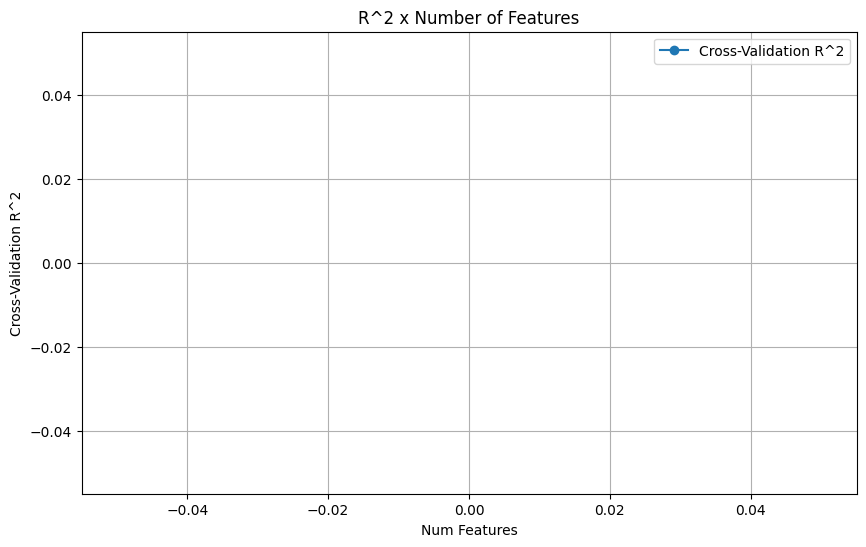

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(num_features, cv_scores, marker='o', label='Cross-Validation R^2')
#plt.axvline(optimal_features, color = 'red', linestyle='--', label=f'Optimal Features ({optimal_features}')
plt.title("R^2 x Number of Features")
plt.xlabel("Num Features")
plt.ylabel("Cross-Validation R^2")
plt.legend()
plt.grid()
plt.show()


## Task 4 - Analyze Feature Importance

In [14]:

# Find the optimal number of features
#optimal_features = num_features[np.argvax(cv_scores)]
print(f"Optimal number of features: {optimal_features}")



AttributeError: module 'numpy' has no attribute 'argvax'

## Task 5 - Reflection

1. "What did you learn about feature selection using RFE?"



2. "How does RFE compare to other feature selection methods like LASSO in terms of methodology and results?"



3. "What insights can you draw about the dataset from the selected features?"